In [ ]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(
    "../processed_data/eda_cleaned.csv"
)

In [4]:
df.head().T

,0,1,2,3,4
year,2025,2025,2025,2025,2025
month,1,1,1,1,1
carrier,G4,G4,G4,G4,G4
carrier_name,Allegiant Air,Allegiant Air,Allegiant Air,Allegiant Air,Allegiant Air
airport,ELM,ELP,EUG,EVV,EWR
airport_name,"Elmira/Corning, NY: Elmira/Corning Regional","El Paso, TX: El Paso International","Eugene, OR: Mahlon Sweet Field","Evansville, IN: Evansville Regional","Newark, NJ: Newark Liberty International"
arr_flights,30.0,2.0,28.0,18.0,31.0
arr_del15,0.0,0.0,8.0,1.0,5.0
carrier_ct,0.0,0.0,3.74,0.0,2.17
weather_ct,0.0,0.0,0.0,1.0,0.0


In [5]:
df.shape

(397283, 22)

In [10]:
df['peak_delay'] = df['month'].isin([6,7,12]).astype(int)

DEFINING X AND Y VARIABLES

In [13]:
x = df.drop(columns=['carrier_delay', 'weather_delay', 'nas_delay','carrier','airport',
        'security_delay', 'late_aircraft_delay','arr_delay','delay_rate', 'carrier_ct', 
        'weather_ct', 'nas_ct', 'security_ct','arr_del15',
       'late_aircraft_ct', 'arr_cancelled', 'arr_diverted'])

In [14]:
x.columns

Index(['year', 'month', 'carrier_name', 'airport_name', 'arr_flights',
       'peak_delay'],
      dtype='object')

In [15]:
y = df['arr_delay']

In [16]:
x.shape

(397283, 6)

In [17]:
y.shape

(397283,)

In [28]:
from sklearn.model_selection import train_test_split

x_train, x_test,y_train, y_test = train_test_split(x,y,random_state=42, test_size=0.3)

In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ohe = OneHotEncoder(
    handle_unknown="ignore"
)

In [31]:
transformer = ColumnTransformer(
    transformers=[
        (
            "cat",
            ohe,
            ['carrier_name', 'airport_name']
        )
    ],
    remainder='passthrough'
)

In [32]:
x_train_encoded = transformer.fit_transform(x_train)
x_test_encoded = transformer.transform(x_test)

In [34]:
x_train_encoded.shape

(278098, 499)

In [35]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

In [36]:
pipe_xgbr = Pipeline(
    [
        ('preprocessor', transformer),
        ('model', XGBRegressor(
            objective="reg:squarederror",
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            n_jobs=-1,
            random_state=42
        ))
    ]
)

In [38]:
pipe_xgbr.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['year','month','carrier_name','airport_name','arr_flights','peak_delay']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenate

In [40]:
y_xgbr_test=pipe_xgbr.predict(x_test)
y_xgbr_train = pipe_xgbr.predict(x_train)

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
mae_train = mean_absolute_error(y_train,y_xgbr_train)
mae_test = mean_absolute_error(y_test,y_xgbr_test)
rmse_train = mean_squared_error(y_train,y_xgbr_train)
rmse_test = mean_squared_error(y_test,y_xgbr_test)
r2_train = r2_score(y_train,y_xgbr_train)
r2_test = r2_score(y_test,y_xgbr_test)

In [44]:
print("MAE for test: ",mae_test)
print("MAE for train: ",mae_train)
print("RMSE for test: ",rmse_test)
print("RMSE for train: ",rmse_train)
print("r2 for test: ",r2_test)
print("r2 for train: ",r2_train)

MAE for test:  1224.3169999537222
MAE for train:  1157.5483848888955
RMSE for test:  14915995.475105477
RMSE for train:  11286183.975647256
r2 for test:  0.907555310133328
r2 for train:  0.93095121898903


In [ ]:
preprocessor = pipe_xgbr.named_steps["preprocessor"]
model = pipe_xgbr.named_steps["model"]

In [46]:
feature_names = preprocessor.get_feature_names_out()

In [51]:
feature_names

array(['cat__carrier_name_ATA Airlines d/b/a ATA',
       'cat__carrier_name_Air Wisconsin Airlines Corp',
       'cat__carrier_name_AirTran Airways Corporation',
       'cat__carrier_name_Alaska Airlines Inc.',
       'cat__carrier_name_Alaska Airlines Network',
       'cat__carrier_name_Allegiant Air',
       'cat__carrier_name_Aloha Airlines Inc.',
       'cat__carrier_name_America West Airlines Inc.',
       'cat__carrier_name_American Airlines Inc.',
       'cat__carrier_name_American Airlines Network',
       'cat__carrier_name_American Eagle Airlines Inc.',
       'cat__carrier_name_Atlantic Coast Airlines',
       'cat__carrier_name_Atlantic Southeast Airlines',
       'cat__carrier_name_Cape Air', 'cat__carrier_name_Comair Inc.',
       'cat__carrier_name_Commutair Aka Champlain Enterprises, Inc.',
       'cat__carrier_name_CommuteAir LLC dba CommuteAir',
       'cat__carrier_name_Compass Airlines',
       'cat__carrier_name_Continental Air Lines Inc.',
       'cat__carrier_na

In [53]:
print(type(x_train_encoded))

<class 'scipy.sparse._csr.csr_matrix'>


In [54]:
x_train_encoded = preprocessor.transform(x_train)
x_test_encoded = preprocessor.transform(x_test)

In [56]:
import shap

In [57]:
explainer = shap.TreeExplainer(model)

In [64]:
shap_values = explainer(x_test_encoded)

In [65]:
shap_values.feature_names = feature_names

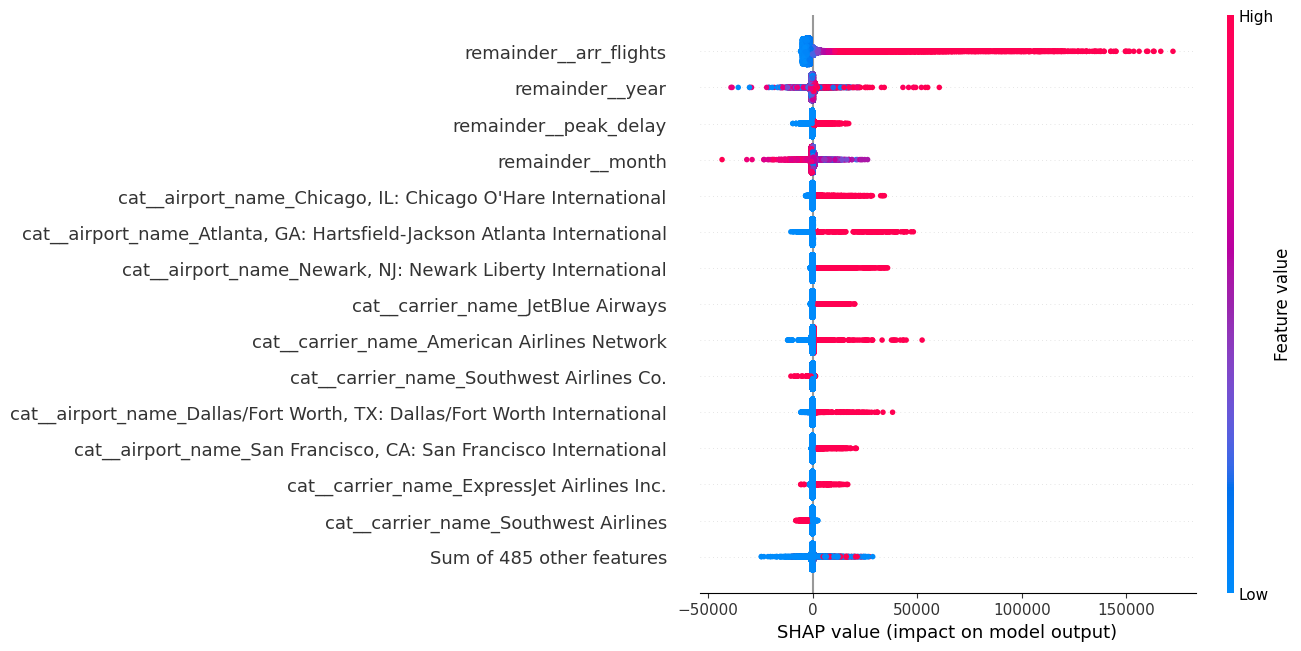

In [66]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

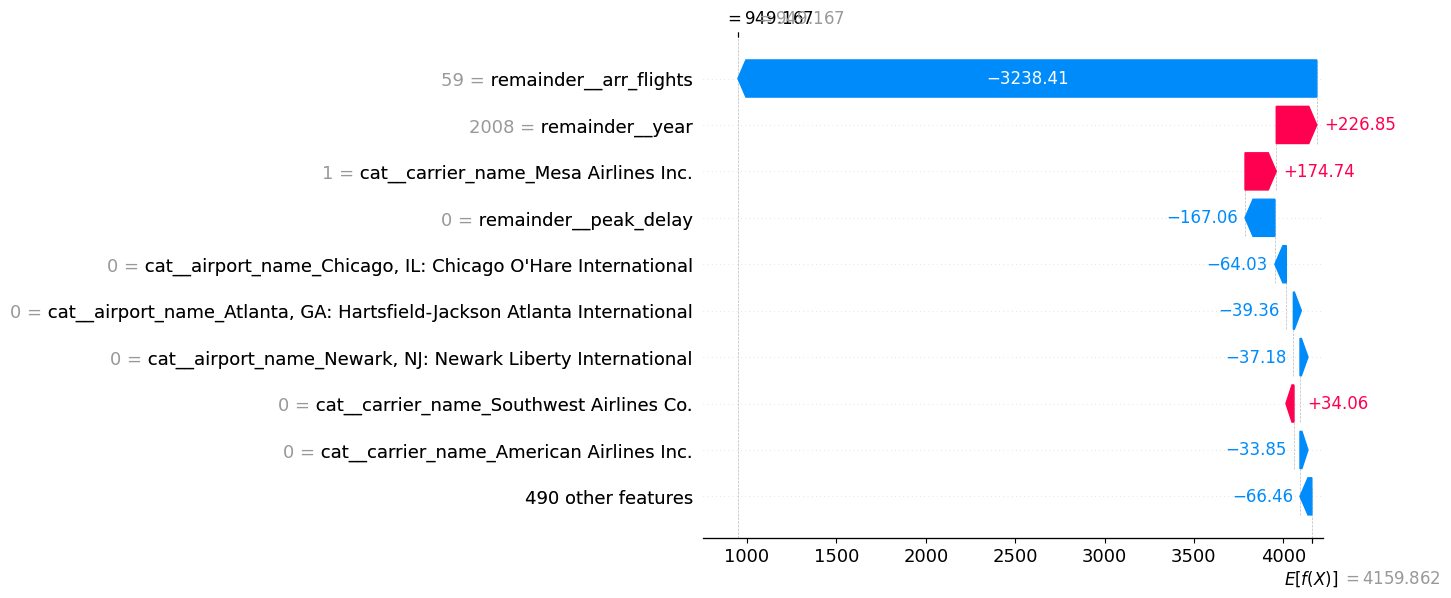

In [68]:
shap.plots.waterfall(shap_values[2])

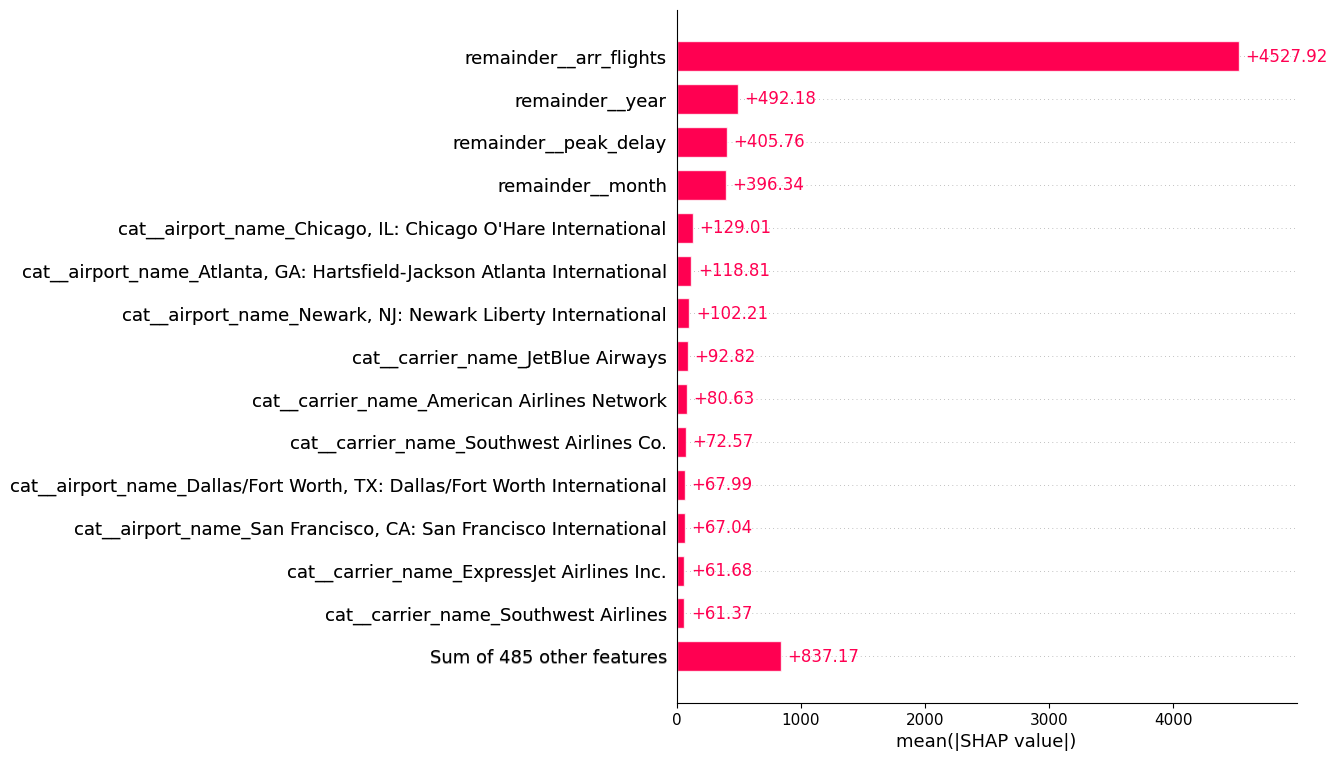

In [69]:
shap.plots.bar(shap_values, max_display=15)

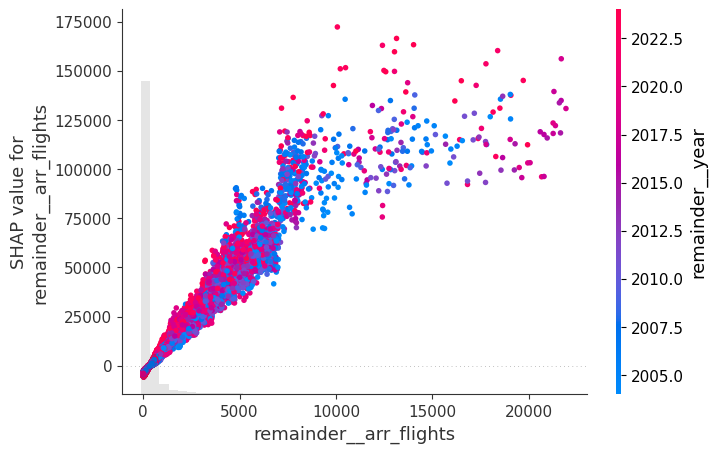

In [71]:
shap.plots.scatter(shap_values[:, "remainder__arr_flights"], color=shap_values[:, "remainder__year"])